In [1]:
#useful python libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
#sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

In [2]:
#load my data
df = pd.read_parquet("my_feature_space.parquet")

df.head()

,objectId,finkclass,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF17aaaadkj,CataclyV*,17.222114,17.174713,0.237890,17.224249,1.171396,0.195322,0.108385,0.481224,...,0.676086,410.613047,0.126921,0.457310,1.825376,0.013813,13.875019,242.808733,-2.438629,0.585522
1,ZTF17aaaagyq,CataclyV*,16.735330,16.498882,0.637000,16.862818,1.910264,0.197590,0.152603,1.436352,...,0.429171,354.654346,0.234251,0.414458,2.552179,0.038063,43.600593,2694.289711,-1.706663,0.709195
2,ZTF17aaaaqna,Unknown,14.323769,14.321861,0.206714,14.224896,0.440336,0.169289,0.109419,0.441297,...,0.723493,95.102274,0.062597,0.344004,0.750938,0.014432,138.605800,238.412293,1.464617,0.796598
3,ZTF17aaaarmr,CataclyV*,16.282178,16.256730,0.240892,16.229107,1.577422,0.129736,0.238448,0.418315,...,0.507220,137.920000,0.074253,0.771527,2.849228,0.014795,61.877870,121.862796,5.046224,0.701406
4,ZTF17aaaazob,CataclyV*,17.864093,17.649710,0.403722,17.859806,2.242684,0.179581,0.082159,0.778325,...,0.627876,696.187235,0.198764,0.561076,3.199834,0.022600,49.381505,620.820245,-2.514259,0.488813


In [3]:
#check shape
df.shape

(2056, 28)

In [4]:
# 1 = CataclyV (including candidates)
# 0 = everything else

y_true = df['finkclass'].apply(
    lambda x: 1 if 'Cat' in str(x) else 0     #true class title
).values

print("Class distribution:")

Class distribution:


In [5]:
# Load saved model
model = joblib.load("cv_classifier_xgb_boost_biggie_set.pkl")

In [6]:
#feature space
feature_columns = df.drop(columns=['objectId', 'finkclass']).columns #drop non_numeric columns

X = df[feature_columns].values #feature column

In [7]:
y_pred = model.predict(X) #predict model

In [8]:
print("Unique predictions:", np.unique(y_pred)) #cross check

Unique predictions: [0 1]


In [9]:
print("Accuracy:", accuracy_score(y_true, y_pred)) #accuracy check

Accuracy: 0.7363813229571985


True CVS: 685
False CVS: 252
True Unknowns: 829
False Unknowns: 290


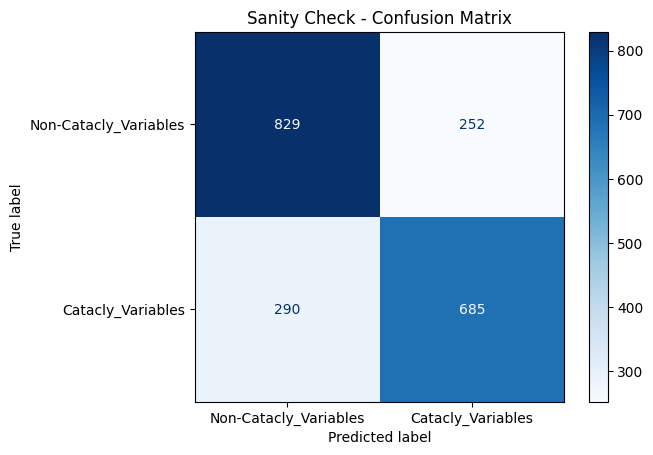

In [10]:
#prediction
#I had 975 cvs and 1081 unknowns
# Step 1: computing confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Step 2: unpacking
tn, fp, fn, tp = cm.ravel()

# Step 3: assign names for better understanding
true_cvs = tp
false_cvs = fp
true_unknowns = tn
false_unknowns = fn

# Step 4: print
print("True CVS:", true_cvs)
print("False CVS:", false_cvs)
print("True Unknowns:", true_unknowns)
print("False Unknowns:", false_unknowns)

# Step 5: plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Catacly_Variables", "Catacly_Variables"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Sanity Check - Confusion Matrix")
plt.show()

In [11]:
#f1 score for minority class:cvs
f1 = f1_score(y_true, y_pred, pos_label=1)
print("F1 Score (minority class):", f1)

F1 Score (minority class): 0.7165271966527197


In [12]:
#f1 score for minority class:unknowns
f1 = f1_score(y_true, y_pred, pos_label=0)
print("F1 Score (majority class):", f1)

F1 Score (majority class): 0.7536363636363637


In [13]:
# align dataframe 
df = df.reset_index(drop=True) #Reset row index, drop old index

# store predictions
df["y_true"] = y_true
df["y_pred"] = y_pred

# False Positives (contaminants)
fp_df = df[(df.y_true == 0) & (df.y_pred == 1)]

# False Negatives (missed CVs)
fn_df = df[(df.y_true == 1) & (df.y_pred == 0)]
#pr
print("FP:", len(fp_df))
print("FN:", len(fn_df))

fp_df[["objectId"]].head()
fn_df[["objectId"]].head()

FP: 252
FN: 290


,objectId
1,ZTF17aaaagyq
3,ZTF17aaaarmr
5,ZTF17aaabarf
15,ZTF17aaaecen
16,ZTF17aaaeefu


In [14]:
#Reset row index, drop old index
df = df.reset_index(drop=True)
# Convert the predicted binary labels (0,1) from the model into readable class names
# 0 : Non-Catacly_Variables, 1 : Catacly_Variables
# y_pred is a NumPy array, so we convert it to a pandas Series to use .map()
df["pred_finkclass"] = pd.Series(y_pred).map({
    0: "Non-Catacly_Variables",
    1: "Catacly_Variables"
})

In [15]:
# False Positives (contaminants)
fp_df = df[(y_true == 0) & (y_pred == 1)]
# False Negatives (missed CVs)
fn_df = df[(y_true == 1) & (y_pred == 0)]

In [16]:
#columns to keep
cols = ["objectId", "finkclass", "pred_finkclass"]

In [17]:
#false positives
fp_df = fp_df[cols]
#show
fp_df.head()

,objectId,finkclass,pred_finkclass
34,ZTF17aaagtoh,Unknown,Catacly_Variables
73,ZTF17aaapqad,Unknown,Catacly_Variables
90,ZTF17aaatgri,Unknown,Catacly_Variables
104,ZTF17aaaxhyd,Unknown,Catacly_Variables
133,ZTF17aabszcj,Unknown,Catacly_Variables


In [18]:
#false negatives
fn_df = fn_df[cols]
#show
fn_df.head()

,objectId,finkclass,pred_finkclass
1,ZTF17aaaagyq,CataclyV*,Non-Catacly_Variables
3,ZTF17aaaarmr,CataclyV*,Non-Catacly_Variables
5,ZTF17aaabarf,CataclyV*,Non-Catacly_Variables
15,ZTF17aaaecen,CataclyV*,Non-Catacly_Variables
16,ZTF17aaaeefu,CataclyV*,Non-Catacly_Variables


              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1081
           1       0.73      0.70      0.72       975

    accuracy                           0.74      2056
   macro avg       0.74      0.73      0.74      2056
weighted avg       0.74      0.74      0.74      2056

